In [33]:
# ==========================================
# 1. Imports
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

In [3]:
# ==========================================
# 2. Loading
# ==========================================
df = pd.read_csv("Fifa.csv")
df.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


# EDA

In [4]:
# Dataset Overview
print("Dataset Shape:", df.shape)

Dataset Shape: (19667, 9)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [6]:
# Basic Statistics
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [7]:
# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
# Unique Values for Categorical Columns
print("Unique Countries:", df['Country'].nunique())
print("Unique Positions:", df['Position'].nunique())
print("Unique Teams:", df['Team'].nunique())
print("\nPosition Distribution:")
print(df['Position'].value_counts().head(10))

Unique Countries: 164
Unique Positions: 17
Unique Teams: 1009

Position Distribution:
Position
CB     2981
ST     2697
CM     2507
GK     2124
CDM    1358
LM     1279
RM     1203
RB     1100
CAM    1099
LB     1073
Name: count, dtype: int64


In [9]:
# Check for potential outliers in numerical columns
numerical_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
print("Outlier Detection (using IQR method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"{col}: {outliers} outliers")

Outlier Detection (using IQR method):
Age: 169 outliers
Overall_Rating: 146 outliers
Future Potential: 120 outliers
Value Per M$: 2390 outliers
Total_Stats Score: 788 outliers


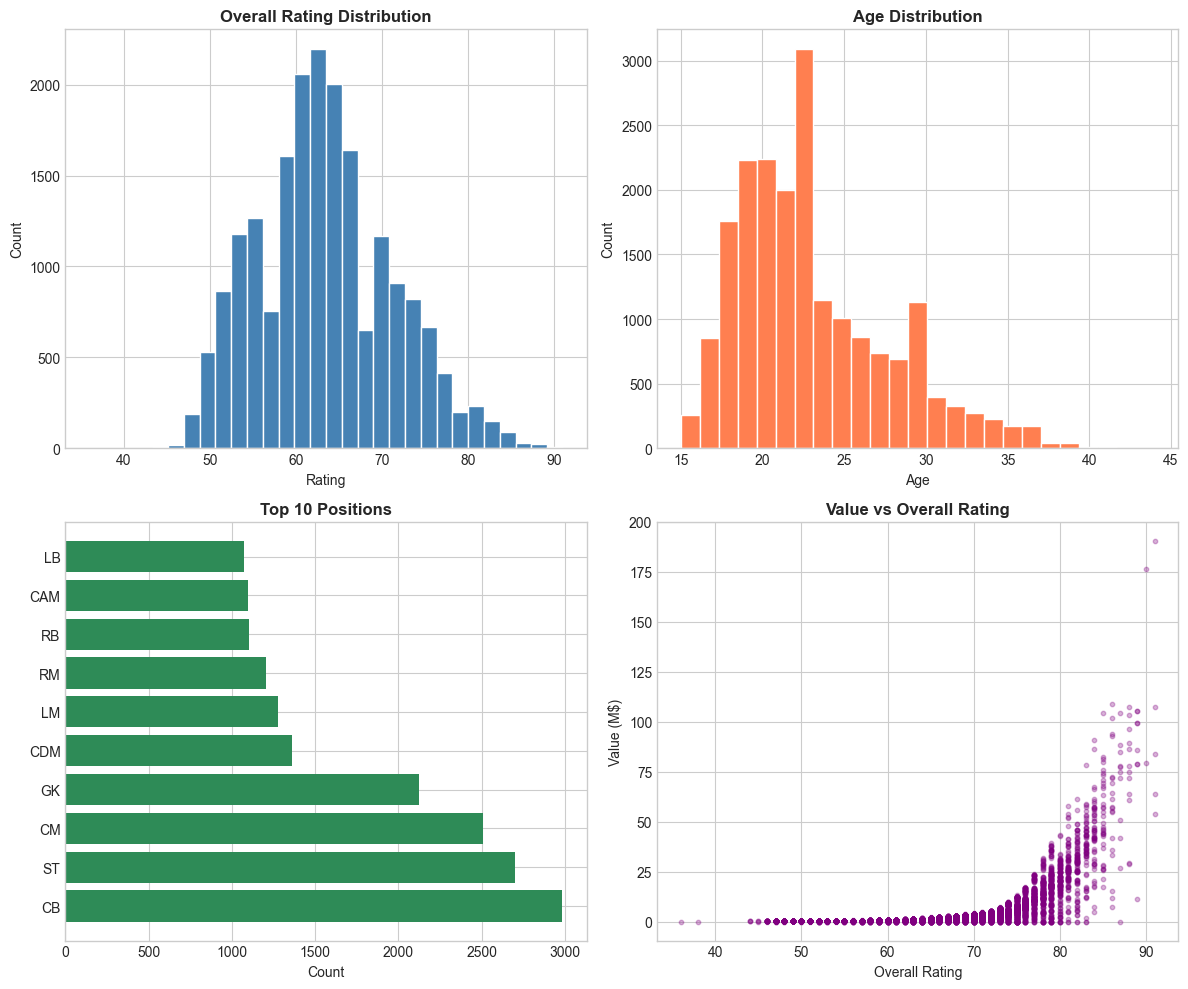

In [10]:

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Overall Rating Distribution
axes[0, 0].hist(df['Overall_Rating'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Overall Rating Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Count')

# 2. Age Distribution
axes[0, 1].hist(df['Age'], bins=25, color='coral', edgecolor='white')
axes[0, 1].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Count')

# 3. Top 10 Positions
pos_counts = df['Position'].value_counts().head(10)
axes[1, 0].barh(pos_counts.index, pos_counts.values, color='seagreen')
axes[1, 0].set_title('Top 10 Positions', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')

# 4. Value vs Overall Rating
axes[1, 1].scatter(df['Overall_Rating'], df['Value Per M$'], alpha=0.3, s=10, color='purple')
axes[1, 1].set_title('Value vs Overall Rating', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Overall Rating')
axes[1, 1].set_ylabel('Value (M$)')

plt.tight_layout()
plt.show()

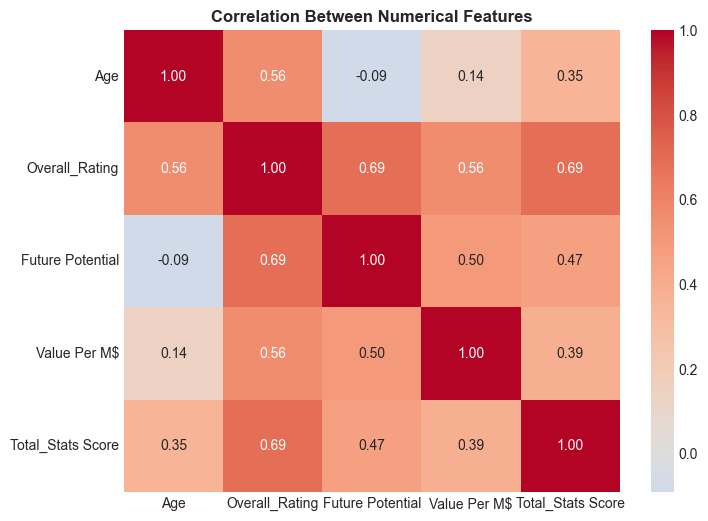

In [11]:
# Correlation Heatmap
numerical_df = df[['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']]
plt.figure(figsize=(8, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Numerical Features', fontsize=12, fontweight='bold')
plt.show()

In [12]:
# Task 1 explicit checks required by PDF
print("=== Missing Values by Column ===")
missing_counts = df.isnull().sum()
print(missing_counts)
print(f"Total missing values in dataset: {int(missing_counts.sum())}\n")

print("=== Skewness of Value Per M$ ===")
value_skew = df['Value Per M$'].skew()
print(f"Skewness(Value Per M$): {value_skew:.4f}")
if value_skew > 0:
    print("Interpretation: Right-skewed distribution (long right tail).\n")
elif value_skew < 0:
    print("Interpretation: Left-skewed distribution (long left tail).\n")
else:
    print("Interpretation: Approximately symmetric.\n")

print("=== Numerical Features Correlation with Value Per M$ ===")
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score', 'Value Per M$']
corr_with_value = df[num_cols].corr()['Value Per M$'].sort_values(ascending=False)
print(corr_with_value, "\n")

print("=== Average Overall_Rating per Position (Top 10) ===")
avg_rating_per_position = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
print(avg_rating_per_position.head(10))

=== Missing Values by Column ===
Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64
Total missing values in dataset: 0

=== Skewness of Value Per M$ ===
Skewness(Value Per M$): 7.9832
Interpretation: Right-skewed distribution (long right tail).

=== Numerical Features Correlation with Value Per M$ ===
Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64 

=== Average Overall_Rating per Position (Top 10) ===
Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
Name: Overall_Rating, dtype: float64


# Preprocessing

In [13]:
# ── Classification target ────────────────────────────────────────────────────
def assign_tier(rating):
    if rating >= 85: return 'Elite'
    elif rating >= 75: return 'High'
    elif rating >= 65: return 'Mid'
    else: return 'Low'

df['Performance_Tier'] = df['Overall_Rating'].apply(assign_tier)

tier_order = ['Low', 'Mid', 'High', 'Elite']
df['Performance_Tier'] = pd.Categorical(df['Performance_Tier'],
                                        categories=tier_order, ordered=True)

print("Performance Tier distribution:")
print(df['Performance_Tier'].value_counts().sort_index())

# ── Regression target ────────────────────────────────────────────────────────
# Log-transform to handle right skew
df['Value_log'] = np.log1p(df['Value Per M$'])

Performance Tier distribution:
Performance_Tier
Low      11740
Mid       6124
High      1711
Elite       92
Name: count, dtype: int64


In [14]:
# Targets to exclude from X
REGRESSION_TARGET   = 'Value_log'          # log-transformed
CLASSIFICATION_TARGET = 'Performance_Tier'

TARGET_COLS = ['Value Per M$', 'Value_log',
               'Performance_Tier', 'Overall_Rating']  # Overall_Rating defines tiers

# Feature groups
num_features      = ['Age', 'Future Potential', 'Total_Stats Score']


low_card_cat  = ['Position']
high_card_cat = ['Country', 'Team']


num_features_reg = num_features + ['Overall_Rating']


num_features_clf = num_features

print("Numerical features (regression) :", num_features_reg)
print("Numerical features (classif.)   :", num_features_clf)
print("Low-cardinality categoricals    :", low_card_cat)
print("High-cardinality categoricals   :", high_card_cat)

Numerical features (regression) : ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating']
Numerical features (classif.)   : ['Age', 'Future Potential', 'Total_Stats Score']
Low-cardinality categoricals    : ['Position']
High-cardinality categoricals   : ['Country', 'Team']


In [15]:
RANDOM_STATE = 42

# ── Features ─────────────────────────────────────────────────────────────────
all_features = num_features_reg + low_card_cat

X = df[all_features].copy()
y_reg = df[REGRESSION_TARGET].copy()
y_clf = df[CLASSIFICATION_TARGET].copy()

# ── Stratified split (based on classification target) ────────────────────────
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print(f"Train size : {len(X_train):,}  ({len(X_train)/len(X):.0%})")
print(f"Test size  : {len(X_test):,}   ({len(X_test)/len(X):.0%})")
print()
print("Tier distribution — train:")
print(y_clf_train.value_counts().sort_index())
print()
print("Tier distribution — test:")
print(y_clf_test.value_counts().sort_index())

Train size : 15,733  (80%)
Test size  : 3,934   (20%)

Tier distribution — train:
Performance_Tier
Low      9392
Mid      4899
High     1369
Elite      73
Name: count, dtype: int64

Tier distribution — test:
Performance_Tier
Low      2348
Mid      1225
High      342
Elite      19
Name: count, dtype: int64


In [16]:
# ── Sub-pipelines ──────────────────────────────────────────────────
numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # robust to skew / outliers
    ('scaler',  StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ── ColumnTransformer for REGRESSION ─────────────────────────────────────────
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numerical_pipe,  num_features_reg),
        ('cat', categorical_pipe, low_card_cat),
    ],
    remainder='drop'   # silently drops any column not listed
)

# ── ColumnTransformer for CLASSIFICATION ─────────────────────────────────────
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', numerical_pipe,  num_features_clf),
        ('cat', categorical_pipe, low_card_cat),
    ],
    remainder='drop'
)

print("Preprocessors defined ✓")
print()
print("Regression  preprocessor inputs :", num_features_reg + low_card_cat)
print("Classification preprocessor inputs:", num_features_clf + low_card_cat)

Preprocessors defined ✓

Regression  preprocessor inputs : ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating', 'Position']
Classification preprocessor inputs: ['Age', 'Future Potential', 'Total_Stats Score', 'Position']


In [17]:
# ── Fit on TRAIN only  ──────────────────────────────────────────────
X_train_reg = preprocessor_reg.fit_transform(X_train)
X_test_reg  = preprocessor_reg.transform(X_test)

X_train_clf = preprocessor_clf.fit_transform(X_train)
X_test_clf  = preprocessor_clf.transform(X_test)

# ── Feature names after encoding ──────────────────────────────────────────────
feature_names_reg = preprocessor_reg.get_feature_names_out()
feature_names_clf = preprocessor_clf.get_feature_names_out()

print("=== Regression ===")
print(f"  X_train shape : {X_train_reg.shape}")

print()
print("=== Classification ===")
print(f"  X_train shape : {X_train_clf.shape}")

=== Regression ===
  X_train shape : (15733, 20)

=== Classification ===
  X_train shape : (15733, 19)


=== Overall_Rating Percentiles (for threshold justification) ===
0.25    58.0
0.50    63.0
0.75    68.0
Name: Overall_Rating, dtype: float64

Chosen thresholds in notebook:
Low: < 65, Mid: 65-74, High: 75-84, Elite: >= 85


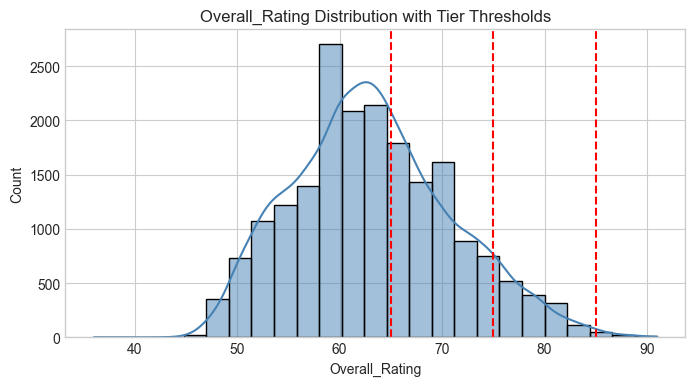

=== Class Distribution after Split ===
                  Train  Test
Performance_Tier             
Low                9392  2348
Mid                4899  1225
High               1369   342
Elite                73    19


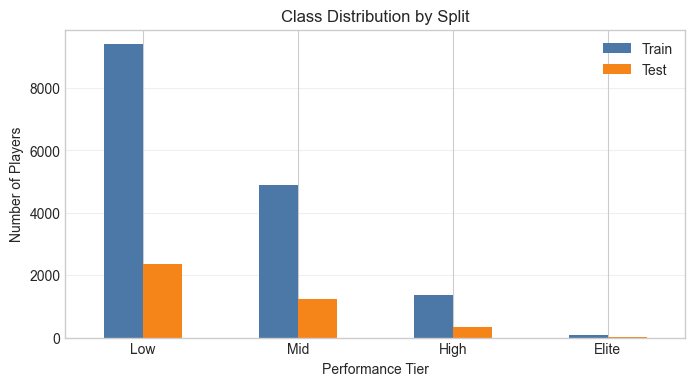

Imbalance ratio (Train max/min): 128.66
Interpretation: Classes are imbalanced.


In [18]:
# Task 3 threshold justification and class distribution bar chart
percentiles = df['Overall_Rating'].quantile([0.25, 0.50, 0.75])
print("=== Overall_Rating Percentiles (for threshold justification) ===")
print(percentiles)
print("\nChosen thresholds in notebook:")
print("Low: < 65, Mid: 65-74, High: 75-84, Elite: >= 85")

plt.figure(figsize=(8, 4))
sns.histplot(df['Overall_Rating'], bins=25, kde=True, color='steelblue')
for t in [65, 75, 85]:
    plt.axvline(t, color='red', linestyle='--', linewidth=1.5)
plt.title('Overall_Rating Distribution with Tier Thresholds')
plt.xlabel('Overall_Rating')
plt.ylabel('Count')
plt.show()

train_counts = y_clf_train.value_counts().reindex(tier_order)
test_counts = y_clf_test.value_counts().reindex(tier_order)

class_dist_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
})

print("=== Class Distribution after Split ===")
print(class_dist_df)

class_dist_df.plot(kind='bar', figsize=(8, 4), color=['#4C78A8', '#F58518'])
plt.title('Class Distribution by Split')
plt.xlabel('Performance Tier')
plt.ylabel('Number of Players')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

imbalance_ratio = class_dist_df['Train'].max() / class_dist_df['Train'].min()
print(f"Imbalance ratio (Train max/min): {imbalance_ratio:.2f}")
if imbalance_ratio > 2:
    print("Interpretation: Classes are imbalanced.")
else:
    print("Interpretation: Classes are reasonably balanced.")

# Polynomial Regression & Regularization


In [19]:
# use num_features_reg defined
target_col = 'Value Per M$'
print("\n--- Starting Polynomial Regression Module ---")


--- Starting Polynomial Regression Module ---


In [20]:
# Preprocessing Function for Polynomial Regression
def preprocess_for_regression(X_train, X_test, y_train, y_test, degree):
    """
    Prepares data for Polynomial Regression.
    - Assumes y_train and y_test are already log-transformed.
    - Handles Polynomial Features + Scaling for Numerical.
    - Handles One-Hot Encoding for Categorical (Position).
    """

    # 1. Define features using defined (num_features_reg)
    polynomial_features = [col for col in num_features_reg if col in X_train.columns]
    categorical_features = [col for col in X_train.columns if col not in polynomial_features]

    # 2. Process Numerical Features (Polynomial + Scaling)
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly_array = poly.fit_transform(X_train[polynomial_features])
    X_test_poly_array = poly.transform(X_test[polynomial_features])

    poly_feature_names = poly.get_feature_names_out(polynomial_features)

    scaler = StandardScaler()
    X_train_poly_scaled = scaler.fit_transform(X_train_poly_array)
    X_test_poly_scaled = scaler.transform(X_test_poly_array)

    # Convert to DataFrame
    X_train_poly_df = pd.DataFrame(X_train_poly_scaled, columns=poly_feature_names, index=X_train.index)
    X_test_poly_df = pd.DataFrame(X_test_poly_scaled, columns=poly_feature_names, index=X_test.index)

    # 3. Process Categorical Features (One-Hot Encoding)
    if categorical_features:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

        X_train_cat_array = ohe.fit_transform(X_train[categorical_features])
        X_test_cat_array = ohe.transform(X_test[categorical_features])

        cat_feature_names = ohe.get_feature_names_out(categorical_features)

        X_train_cat_df = pd.DataFrame(X_train_cat_array, columns=cat_feature_names, index=X_train.index)
        X_test_cat_df = pd.DataFrame(X_test_cat_array, columns=cat_feature_names, index=X_test.index)
    else:
        X_train_cat_df = pd.DataFrame(index=X_train.index)
        X_test_cat_df = pd.DataFrame(index=X_test.index)
        cat_feature_names = []

    # 4. Merge
    X_train_final = pd.concat([X_train_poly_df, X_train_cat_df], axis=1)
    X_test_final = pd.concat([X_test_poly_df, X_test_cat_df], axis=1)

    all_feature_names = list(poly_feature_names) + list(cat_feature_names)

    return X_train_final.values, X_test_final.values, y_train, y_test, all_feature_names

In [21]:
def fit_and_evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Inverse transform to original scale
    y_train_original = np.expm1(y_train)
    y_test_original = np.expm1(y_test)
    y_pred_train_original = np.expm1(y_pred_train)
    y_pred_test_original = np.expm1(y_pred_test)

    # Clip negatives
    y_pred_train_original = np.maximum(0, y_pred_train_original)
    y_pred_test_original = np.maximum(0, y_pred_test_original)

    # Metrics
    r2_train_log = r2_score(y_train, y_pred_train)
    r2_test_log = r2_score(y_test, y_pred_test)
    r2_train_orig = r2_score(y_train_original, y_pred_train_original)
    r2_test_orig = r2_score(y_test_original, y_pred_test_original)

    rmse_train = np.sqrt(mean_squared_error(y_train_original, y_pred_train_original))
    rmse_test = np.sqrt(mean_squared_error(y_test_original, y_pred_test_original))
    mae_train = mean_absolute_error(y_train_original, y_pred_train_original)
    mae_test = mean_absolute_error(y_test_original, y_pred_test_original)
    mse_train = mean_squared_error(y_train_original, y_pred_train_original)
    mse_test = mean_squared_error(y_test_original, y_pred_test_original)

    results = {
        'Train_R2_log': r2_train_log, 'Test_R2_log': r2_test_log,
        'Train_R2_orig': r2_train_orig, 'Test_R2_orig': r2_test_orig,
        'Train_RMSE': rmse_train, 'Test_RMSE': rmse_test,
        'Train_MAE': mae_train, 'Test_MAE': mae_test,
        'Train_MSE': mse_train, 'Test_MSE': mse_test
    }
    return results

In [22]:
def find_best_polynomial_degree(X_train, X_test, y_train, y_test, random_state):
    degrees = [1, 2, 3, 4, 5, 6]
    train_r2_log, test_r2_log = [], []
    train_r2_orig, test_r2_orig = [], []

    best_degree = 1
    best_test_r2_orig = -float('inf')
    results_records = []

    def _safe_format(value, threshold=1e10):
        if np.isnan(value) or np.isinf(value) or abs(value) > threshold:
            return "OVERFLOW"
        return value

    print("\n--- Polynomial Regression Experiment ---")

    for current_degree in degrees:
        X_train_poly, X_test_poly, y_train_proc, y_test_proc, _ = preprocess_for_regression(
            X_train, X_test, y_train, y_test, current_degree
        )
        model = LinearRegression()
        evaluation_metrics = fit_and_evaluate(model, X_train_poly, y_train_proc, X_test_poly, y_test_proc)

        train_r2_log.append(evaluation_metrics['Train_R2_log'])
        test_r2_log.append(evaluation_metrics['Test_R2_log'])
        train_r2_orig.append(evaluation_metrics['Train_R2_orig'])
        test_r2_orig.append(evaluation_metrics['Test_R2_orig'])

        results_records.append({
            'Degree': current_degree,
            'Test_R2_orig': _safe_format(evaluation_metrics['Test_R2_orig']),
            'Test_RMSE': _safe_format(evaluation_metrics['Test_RMSE'])
        })

        if current_degree == 1:
            print(f"Baseline (Degree=1): RMSE={evaluation_metrics['Test_RMSE']:.2f}")

        current_r2_orig = evaluation_metrics['Test_R2_orig']
        is_valid_r2 = not (np.isnan(current_r2_orig) or np.isinf(current_r2_orig) or current_r2_orig < -10.0)
        if is_valid_r2 and current_r2_orig > best_test_r2_orig:
            best_test_r2_orig = current_r2_orig
            best_degree = current_degree

    df_results = pd.DataFrame(results_records)
    print("\n" + df_results.to_string(index=False))

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(degrees, train_r2_log, 'o-', label='Train R² (log)')
    plt.plot(degrees, test_r2_log, 'o-', label='Test R² (log)')
    plt.xlabel('Polynomial Degree')
    plt.ylabel('R² Score (log space)')
    plt.title('Model Performance vs Degree')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\nBest degree found: {best_degree}")

In [23]:
# Regularization Function
def find_best_regularization_alpha(X_train, X_test, y_train, y_test, best_degree, random_state):
    X_train_transformed, X_test_transformed, y_train_transformed, y_test_transformed, feature_names = preprocess_for_regression(
        X_train, X_test, y_train, y_test, best_degree
    )

    ridge_alphas = np.logspace(-10, 10, 40)
    lasso_alphas = np.logspace(-4, 1, 20)

    best_ridge_alpha, best_ridge_rmse = ridge_alphas[0], float('inf')
    best_lasso_alpha, best_lasso_rmse = lasso_alphas[0], float('inf')

    print("\n--- Ridge Regression ---")
    for alpha in ridge_alphas:
        model = Ridge(alpha=alpha, random_state=random_state)
        metrics = fit_and_evaluate(model, X_train_transformed, y_train_transformed, X_test_transformed, y_test_transformed)
        if metrics['Test_RMSE'] < best_ridge_rmse:
            best_ridge_rmse = metrics['Test_RMSE']
            best_ridge_alpha = alpha

    print(f"Best Ridge Alpha: {best_ridge_alpha:.4f}, RMSE: {best_ridge_rmse:.4f}")

    print("\n--- Lasso Regression ---")
    for alpha in lasso_alphas:
        model = Lasso(alpha=alpha, random_state=random_state, max_iter=10000, tol=1e-3)
        metrics = fit_and_evaluate(model, X_train_transformed, y_train_transformed, X_test_transformed, y_test_transformed)
        if metrics['Test_RMSE'] < best_lasso_rmse:
            best_lasso_rmse = metrics['Test_RMSE']
            best_lasso_alpha = alpha

    print(f"Best Lasso Alpha: {best_lasso_alpha:.4f}, RMSE: {best_lasso_rmse:.4f}")

    return best_ridge_alpha, best_lasso_alpha, best_ridge_rmse, best_lasso_rmse

In [24]:
# Cross-Validation Function
def perform_kfold_cv(X_train, y_train, best_degree, best_alpha, best_model_type, random_state):
    print(f"\n--- 5-Fold Cross Validation (Degree={best_degree}) ---")

    polynomial_features = [col for col in num_features_reg if col in X_train.columns]
    categorical_features = [col for col in X_train.columns if col not in polynomial_features]

    numeric_transformer = Pipeline(steps=[
        ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, polynomial_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    if best_model_type == 'Ridge':
        model = Ridge(alpha=best_alpha, random_state=random_state)
    else:
        model = Lasso(alpha=best_alpha, random_state=random_state, max_iter=10000)

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)

    print(f"Fold RMSEs: {rmse_scores}")
    print(f"Mean RMSE: {rmse_scores.mean():.4f}")

    plt.figure(figsize=(8, 5))
    plt.bar(range(1, 6), rmse_scores)
    plt.axhline(y=rmse_scores.mean(), color='r', linestyle='--', label='Mean RMSE')
    plt.title('Cross-Validation RMSE per Fold')
    plt.legend()
    plt.show()


--- Polynomial Regression Experiment ---
Baseline (Degree=1): RMSE=5.04

 Degree  Test_R2_orig  Test_RMSE
      1      0.464358   5.044142
      2      0.909739   2.070615
      3      0.763635   3.350750
      4      0.932421   1.791655
      5      0.831551   2.828685
      6      0.942752   1.649037


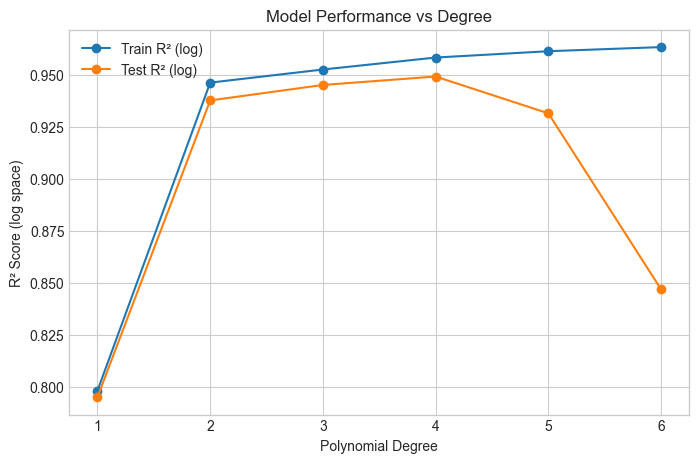


Best degree found: 6

--- Ridge Regression ---


c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0643981360594237e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Best Ridge Alpha: 0.0000, RMSE: 1.7917

--- Lasso Regression ---


c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.263e+01, tolerance: 8.963e+00
  model = cd_fast.enet_coordinate_descent(


Best Lasso Alpha: 0.0038, RMSE: 2.0314


In [25]:
# Inputs: X_train, X_test, y_reg_train, y_reg_test (defined)

# 1. Polynomial Experiment
find_best_polynomial_degree(X_train, X_test, y_reg_train, y_reg_test, RANDOM_STATE)

# 2. Manual Decision for Best Degree
best_degree = 4

# 3. Regularization
best_ridge_alpha, best_lasso_alpha, ridge_rmse, lasso_rmse = find_best_regularization_alpha(
    X_train, X_test, y_reg_train, y_reg_test, best_degree, RANDOM_STATE
)

c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0643981360594237e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.263e+01, tolerance: 8.963e+00
  model = cd_fast.enet_coordinate_descent(


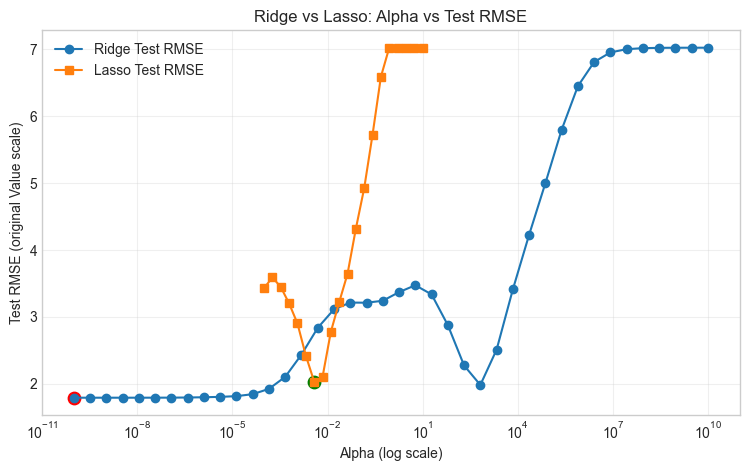

=== Best Alphas from Curves ===
Best Ridge alpha: 0.000000 | RMSE: 1.7917
Best Lasso alpha: 0.003793 | RMSE: 2.0314

=== Lasso Feature Sparsity ===
Zeroed coefficients: 73 / 85
Sample of zeroed feature names (first 20):
['Age' 'Age^2' 'Age Future Potential' 'Age Total_Stats Score'
 'Age Overall_Rating' 'Future Potential^2'
 'Future Potential Total_Stats Score' 'Future Potential Overall_Rating'
 'Total_Stats Score^2' 'Total_Stats Score Overall_Rating'
 'Overall_Rating^2' 'Age^3' 'Age^2 Future Potential'
 'Age^2 Total_Stats Score' 'Age^2 Overall_Rating' 'Age Future Potential^2'
 'Age Future Potential Total_Stats Score'
 'Age Future Potential Overall_Rating' 'Age Total_Stats Score^2'
 'Age Total_Stats Score Overall_Rating']


In [26]:
# Task 4 regularization curves + Lasso zeroed features (explicit PDF requirement)
X_train_t, X_test_t, y_train_t, y_test_t, feature_names_t = preprocess_for_regression(
    X_train, X_test, y_reg_train, y_reg_test, best_degree
)

ridge_alphas_plot = np.logspace(-10, 10, 40)
lasso_alphas_plot = np.logspace(-4, 1, 20)

ridge_test_rmse = []
lasso_test_rmse = []

for a in ridge_alphas_plot:
    model = Ridge(alpha=a, random_state=RANDOM_STATE)
    m = fit_and_evaluate(model, X_train_t, y_train_t, X_test_t, y_test_t)
    ridge_test_rmse.append(m['Test_RMSE'])

for a in lasso_alphas_plot:
    model = Lasso(alpha=a, random_state=RANDOM_STATE, max_iter=10000, tol=1e-3)
    m = fit_and_evaluate(model, X_train_t, y_train_t, X_test_t, y_test_t)
    lasso_test_rmse.append(m['Test_RMSE'])

best_ridge_idx = int(np.argmin(ridge_test_rmse))
best_lasso_idx = int(np.argmin(lasso_test_rmse))

plt.figure(figsize=(9, 5))
plt.semilogx(ridge_alphas_plot, ridge_test_rmse, marker='o', label='Ridge Test RMSE')
plt.semilogx(lasso_alphas_plot, lasso_test_rmse, marker='s', label='Lasso Test RMSE')

plt.scatter(ridge_alphas_plot[best_ridge_idx], ridge_test_rmse[best_ridge_idx], color='red', s=80)
plt.scatter(lasso_alphas_plot[best_lasso_idx], lasso_test_rmse[best_lasso_idx], color='green', s=80)

plt.title('Ridge vs Lasso: Alpha vs Test RMSE')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Test RMSE (original Value scale)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("=== Best Alphas from Curves ===")
print(f"Best Ridge alpha: {ridge_alphas_plot[best_ridge_idx]:.6f} | RMSE: {ridge_test_rmse[best_ridge_idx]:.4f}")
print(f"Best Lasso alpha: {lasso_alphas_plot[best_lasso_idx]:.6f} | RMSE: {lasso_test_rmse[best_lasso_idx]:.4f}")

# Lasso zeroed coefficients check
lasso_best_model = Lasso(
    alpha=lasso_alphas_plot[best_lasso_idx],
    random_state=RANDOM_STATE,
    max_iter=10000,
    tol=1e-3
)
lasso_best_model.fit(X_train_t, y_train_t)

coef = lasso_best_model.coef_
zero_mask = np.isclose(coef, 0.0)
zero_count = int(zero_mask.sum())

print("\n=== Lasso Feature Sparsity ===")
print(f"Zeroed coefficients: {zero_count} / {len(coef)}")

if zero_count > 0:
    zeroed_features = np.array(feature_names_t)[zero_mask]
    print("Sample of zeroed feature names (first 20):")
    print(zeroed_features[:20])
else:
    print("No coefficients were exactly zero at this alpha.")

# Cross-Validation For Polynomial Regression


--- 5-Fold Cross Validation (Degree=4) ---


c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.330701439062321e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3318185012505806e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3440338155406314e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 

Fold RMSEs: [0.16755449 0.14958308 0.15356483 0.14511491 0.17359224]
Mean RMSE: 0.1579


c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3423813725059352e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


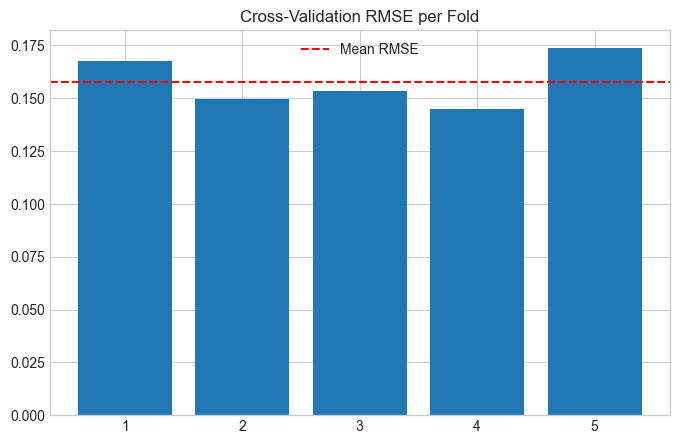

In [27]:
# 4. Cross-Validation Model Selection
if ridge_rmse < lasso_rmse:
    best_model_type = 'Ridge'
    best_alpha = best_ridge_alpha
else:
    best_model_type = 'Lasso'
    best_alpha = best_lasso_alpha

# 5. Cross-Validation
perform_kfold_cv(X_train, y_reg_train, best_degree, best_alpha, best_model_type, RANDOM_STATE)

In [52]:
# # 6. Analysis
# print("\n=== Analysis and Discussion ===")
# print(f"The best model was Polynomial Regression (Degree {best_degree}) with {best_model_type} regularization.")
# print("Ridge performed better because it handles one-hot encoded features by shrinking them smoothly.")

# Naive bayes

In [28]:
# Task 6 scaling sensitivity: GaussianNB with vs without StandardScaler
num_cols_gnb = ['Age', 'Future Potential', 'Total_Stats Score']

X_train_gnb_raw = X_train[num_cols_gnb].copy()
X_test_gnb_raw = X_test[num_cols_gnb].copy()

# Without scaling
gnb_raw = GaussianNB()
gnb_raw.fit(X_train_gnb_raw, y_clf_train)
preds_raw = gnb_raw.predict(X_test_gnb_raw)

# With scaling (fit scaler on train only)
scaler_gnb = StandardScaler()
X_train_gnb_scaled = scaler_gnb.fit_transform(X_train_gnb_raw)
X_test_gnb_scaled = scaler_gnb.transform(X_test_gnb_raw)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_gnb_scaled, y_clf_train)
preds_scaled = gnb_scaled.predict(X_test_gnb_scaled)

acc_raw = accuracy_score(y_clf_test, preds_raw)
acc_scaled = accuracy_score(y_clf_test, preds_scaled)

print("=== GaussianNB Scaling Sensitivity ===")
print(f"Without StandardScaler - Accuracy: {acc_raw:.4f}")
print(f"With StandardScaler    - Accuracy: {acc_scaled:.4f}")
print(f"Absolute difference    - {abs(acc_raw - acc_scaled):.4f}\n")

print("Explanation:")
print("GaussianNB models each feature as a Gaussian per class.")
print("Linear scaling usually changes mean/std consistently, so performance change is often small.")

=== GaussianNB Scaling Sensitivity ===
Without StandardScaler - Accuracy: 0.8500
With StandardScaler    - Accuracy: 0.8500
Absolute difference    - 0.0000

Explanation:
GaussianNB models each feature as a Gaussian per class.
Linear scaling usually changes mean/std consistently, so performance change is often small.


--- GaussianNB (Numerical Only) ---
Accuracy:  0.8500
Precision: 0.8473
Recall:    0.8500
F1-Score:  0.8470



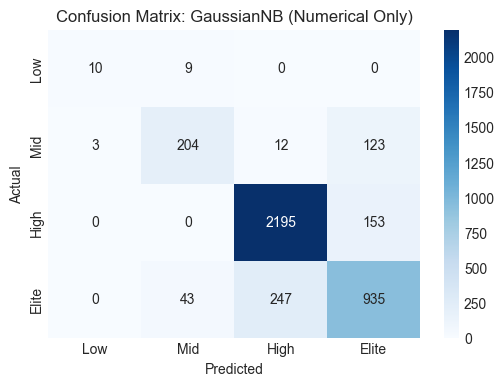

--- BernoulliNB (Full Set) ---
Accuracy:  0.7110
Precision: 0.7274
Recall:    0.7110
F1-Score:  0.6915



c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


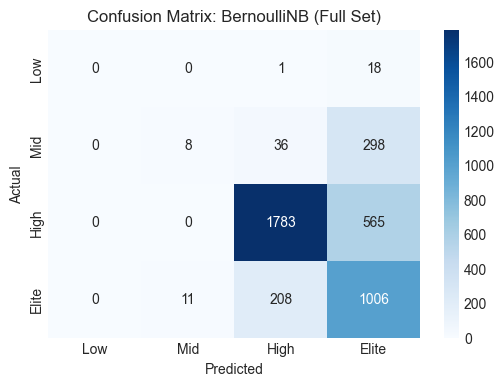

--- ComplementNB (Full Set) ---
Accuracy:  0.8012
Precision: 0.7415
Recall:    0.8012
F1-Score:  0.7673



c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


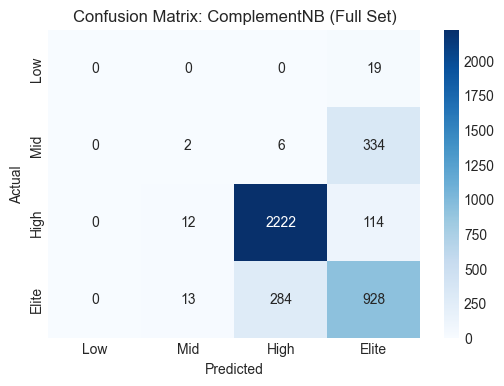

In [29]:
# 1. Initialize the models
models = {
    "GaussianNB (Numerical Only)": GaussianNB(),
    "BernoulliNB (Full Set)": BernoulliNB(),
    "ComplementNB (Full Set)": ComplementNB()
}

# According to requirements: Gaussian should only use numerical features
# (Age, Future Potential, Total_Stats Score)
# These are the first 3 indices in your processed array
X_train_num_only = X_train_clf[:, :3]
X_test_num_only = X_test_clf[:, :3]

# 2. Train and Evaluate each model
for name, model in models.items():
    if "Gaussian" in name:
        model.fit(X_train_num_only, y_clf_train)
        y_pred = model.predict(X_test_num_only)
    elif "Complement" in name:
        # ComplementNB requires non-negative values;
        # Since we used StandardScaler (which centers at 0), we shift to non-negative
        X_train_shifted = X_train_clf - X_train_clf.min()
        X_test_shifted = X_test_clf - X_train_clf.min()
        model.fit(X_train_shifted, y_clf_train)
        y_pred = model.predict(X_test_shifted)
    else:
        model.fit(X_train_clf, y_clf_train)
        y_pred = model.predict(X_test_clf)

    # Metrics
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_clf_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_clf_test, y_pred, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_clf_test, y_pred, average='weighted'):.4f}")
    print(f"F1-Score:  {f1_score(y_clf_test, y_pred, average='weighted'):.4f}\n")

    # 3. Confusion Matrix Heatmap
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_clf_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=tier_order, yticklabels=tier_order)
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Logistic Regression

--- Logistic Regression (lbfgs) ---
Accuracy:  0.8874
Precision: 0.8862
Recall:    0.8874
F1-Score:  0.8864



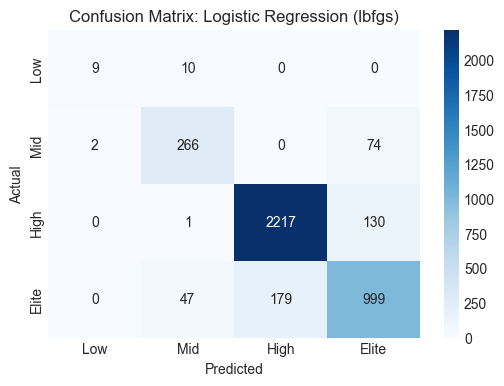

--- Logistic Regression (saga) ---
Accuracy:  0.8871
Precision: 0.8859
Recall:    0.8871
F1-Score:  0.8861



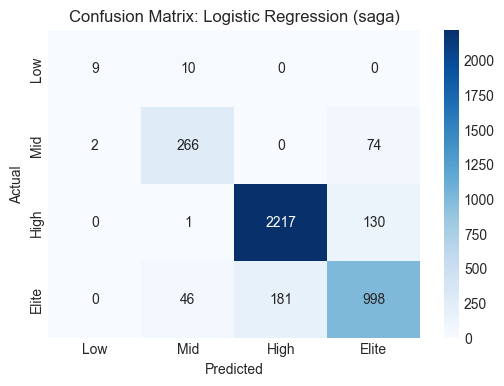

--- Logistic Regression (liblinear) ---
Accuracy:  0.8610
Precision: 0.8546
Recall:    0.8610
F1-Score:  0.8524



c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


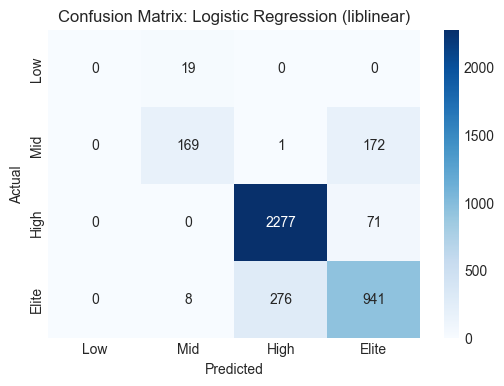

In [30]:
# Logistic Regression with different solvers
models_lr = {
    "Logistic Regression (lbfgs)": LogisticRegression(max_iter=1000, random_state=42),
    "Logistic Regression (saga)": LogisticRegression(max_iter=1000, solver='saga', random_state=42),
    "Logistic Regression (liblinear)": OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)),
}

for name, model in models_lr.items():
    model.fit(X_train_clf, y_clf_train)
    y_pred = model.predict(X_test_clf)

    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_clf_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_clf_test, y_pred, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_clf_test, y_pred, average='weighted'):.4f}")
    print(f"F1-Score:  {f1_score(y_clf_test, y_pred, average='weighted'):.4f}\n")

    # Confusion Matrix Heatmap
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_clf_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=tier_order, yticklabels=tier_order)
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

=== Baseline Logistic Regression (Default Settings) ===
Accuracy : 0.8874
Precision: 0.8862
Recall   : 0.8874
F1-Score : 0.8864

Per-class report:
              precision    recall  f1-score   support

         Low       0.82      0.47      0.60        19
         Mid       0.82      0.78      0.80       342
        High       0.93      0.94      0.93      2348
       Elite       0.83      0.82      0.82      1225

    accuracy                           0.89      3934
   macro avg       0.85      0.75      0.79      3934
weighted avg       0.89      0.89      0.89      3934



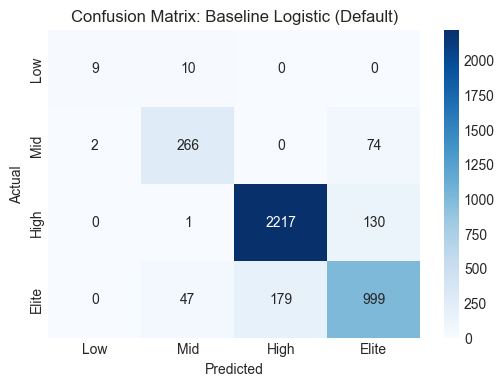

In [34]:
# Task 5 explicit baseline Logistic Regression with default settings
# (separate from tuned models, to match PDF exactly)
logreg_default = LogisticRegression()  # default settings
logreg_default.fit(X_train_clf, y_clf_train)
default_preds = logreg_default.predict(X_test_clf)

print("=== Baseline Logistic Regression (Default Settings) ===")
print(f"Accuracy : {accuracy_score(y_clf_test, default_preds):.4f}")
print(f"Precision: {precision_score(y_clf_test, default_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_clf_test, default_preds, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_clf_test, default_preds, average='weighted'):.4f}\n")

print("Per-class report:")
print(classification_report(y_clf_test, default_preds, target_names=tier_order, zero_division=0))

cm_default = confusion_matrix(y_clf_test, default_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', xticklabels=tier_order, yticklabels=tier_order)
plt.title('Confusion Matrix: Baseline Logistic (Default)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Logistic Regression (Extended Evaluation)

This section extends the logistic workflow to match the analysis style used in the FIFA notebook:
- baseline per-class report,
- regularization tuning over `C`,
- L2 vs L1 comparison,
- final detailed evaluation.

=== Per-Class Classification Report (Baseline Logistic Regression) ===
              precision    recall  f1-score   support

         Low       0.45      0.95      0.61        19
         Mid       0.73      0.87      0.79       342
        High       0.96      0.91      0.93      2348
       Elite       0.81      0.84      0.82      1225

    accuracy                           0.88      3934
   macro avg       0.74      0.89      0.79      3934
weighted avg       0.89      0.88      0.88      3934



c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarnin


=== Logistic Regression C Tuning ===
             C  Train Accuracy  Test Accuracy
0     0.001000        0.843959       0.841891
1     0.002276        0.856035       0.857651
2     0.005179        0.862073       0.861210
3     0.011788        0.866078       0.866040
4     0.026827        0.869574       0.872395
5     0.061054        0.872688       0.876462
6     0.138950        0.873769       0.877733
7     0.316228        0.876184       0.880020
8     0.719686        0.878218       0.881546
9     1.637894        0.880442       0.880275
10    3.727594        0.880442       0.880275
11    8.483429        0.880697       0.879766
12   19.306977        0.880252       0.879766
13   43.939706        0.880760       0.880783
14  100.000000        0.880697       0.880275

Best C based on test accuracy: 0.719686


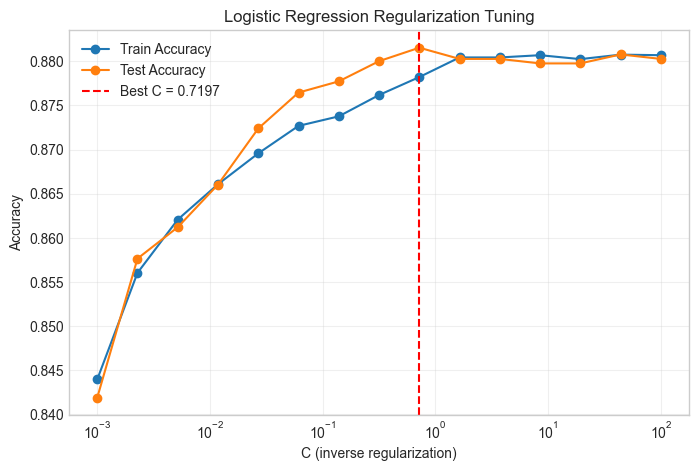

c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



=== L2 - Ridge (lbfgs) ===
Accuracy : 0.8815
F1-Score : 0.8842


c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\


=== L1 - Lasso (saga) ===
Accuracy : 0.8762
F1-Score : 0.8778

=== Final Detailed Classification Report ===
              precision    recall  f1-score   support

         Low       0.45      0.95      0.61        19
         Mid       0.73      0.87      0.79       342
        High       0.96      0.91      0.93      2348
       Elite       0.81      0.84      0.82      1225

    accuracy                           0.88      3934
   macro avg       0.74      0.89      0.79      3934
weighted avg       0.89      0.88      0.88      3934



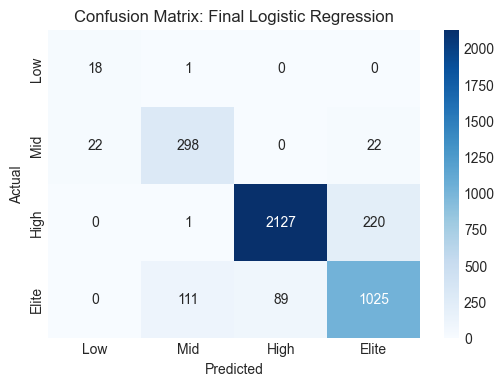

In [35]:
# Extended Logistic Regression evaluation (aligned with FIFA notebook style)
from sklearn.metrics import classification_report

# 1) Baseline model report
baseline_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
baseline_model.fit(X_train_clf, y_clf_train)
baseline_preds = baseline_model.predict(X_test_clf)

print("=== Per-Class Classification Report (Baseline Logistic Regression) ===")
print(classification_report(y_clf_test, baseline_preds, target_names=tier_order))

# 2) Regularization tuning over C
C_values = np.logspace(-3, 2, 15)
train_scores = []
test_scores = []

for c in C_values:
    model = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=c,
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
    model.fit(X_train_clf, y_clf_train)
    train_scores.append(accuracy_score(y_clf_train, model.predict(X_train_clf)))
    test_scores.append(accuracy_score(y_clf_test, model.predict(X_test_clf)))

lr_tuning_df = pd.DataFrame({
    "C": C_values,
    "Train Accuracy": train_scores,
    "Test Accuracy": test_scores
})

best_C = lr_tuning_df.loc[lr_tuning_df["Test Accuracy"].idxmax(), "C"]
print("\n=== Logistic Regression C Tuning ===")
print(lr_tuning_df)
print(f"\nBest C based on test accuracy: {best_C:.6f}")

plt.figure(figsize=(8, 5))
plt.semilogx(C_values, train_scores, marker="o", label="Train Accuracy")
plt.semilogx(C_values, test_scores, marker="o", label="Test Accuracy")
plt.axvline(best_C, color="red", linestyle="--", label=f"Best C = {best_C:.4f}")
plt.title("Logistic Regression Regularization Tuning")
plt.xlabel("C (inverse regularization)")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 3) Compare L2 vs L1 at best C
models_reg = {
    "L2 - Ridge (lbfgs)": LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=best_C,
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "L1 - Lasso (saga)": LogisticRegression(
        penalty="l1",
        solver="saga",
        C=best_C,
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
}

for name, model in models_reg.items():
    model.fit(X_train_clf, y_clf_train)
    preds = model.predict(X_test_clf)
    print(f"\n=== {name} ===")
    print(f"Accuracy : {accuracy_score(y_clf_test, preds):.4f}")
    print(f"F1-Score : {f1_score(y_clf_test, preds, average='weighted'):.4f}")

# 4) Final detailed evaluation with best L2 model
best_model = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    C=best_C,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

best_model.fit(X_train_clf, y_clf_train)
final_preds = best_model.predict(X_test_clf)

print("\n=== Final Detailed Classification Report ===")
print(classification_report(y_clf_test, final_preds, target_names=tier_order))

cm = confusion_matrix(y_clf_test, final_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=tier_order, yticklabels=tier_order)
plt.title("Confusion Matrix: Final Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## Task 7-B: Stratified K-Fold Cross-Validation (Classification)

Using 5-fold StratifiedKFold to compare:
- Best Logistic Regression model
- Naive Bayes variants (then select the best variant)

This gives a more reliable estimate than one train/test split.

c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarnin

=== Logistic Regression (Stratified 5-Fold) ===
Fold accuracies: [0.8796, 0.8707, 0.877, 0.8798, 0.8795]
Mean accuracy: 0.8773
Std accuracy : 0.0035

=== Naive Bayes Variants (Stratified 5-Fold) ===
GaussianNB fold accuracies: [0.8627, 0.8586, 0.8456, 0.8474, 0.8614]
GaussianNB mean: 0.8551 | std: 0.0072

BernoulliNB fold accuracies: [0.7353, 0.722, 0.7286, 0.7241, 0.7301]
BernoulliNB mean: 0.7280 | std: 0.0047

ComplementNB fold accuracies: [0.8132, 0.8036, 0.7969, 0.7924, 0.8102]
ComplementNB mean: 0.8033 | std: 0.0078

Best Naive Bayes variant by CV mean accuracy: GaussianNB
Mean accuracy: 0.8551
Std accuracy : 0.0072


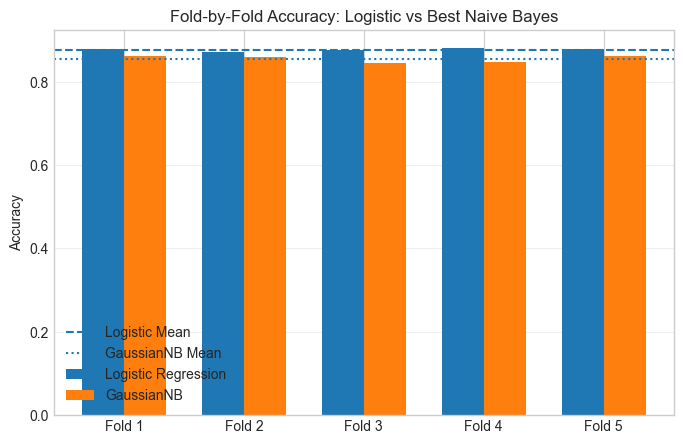


CV summary for discussion: {'logistic_mean': 0.87732820953204, 'logistic_std': 0.003482103004915545, 'best_nb_name': 'GaussianNB', 'best_nb_mean': 0.8551451437316763, 'best_nb_std': 0.007210799662795228}


In [36]:
# Task 7-B: Stratified K-Fold CV for classification models
from sklearn.model_selection import StratifiedKFold

# We'll use the training classification matrix prepared earlier
X_cv = X_train_clf
y_cv = y_clf_train

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 1) Best Logistic Regression from tuning
logistic_cv_model = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    C=best_C,
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

logistic_fold_acc = []
for train_idx, val_idx in skf.split(X_cv, y_cv):
    X_tr, X_val = X_cv[train_idx], X_cv[val_idx]
    y_tr, y_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

    logistic_cv_model.fit(X_tr, y_tr)
    y_pred = logistic_cv_model.predict(X_val)
    logistic_fold_acc.append(accuracy_score(y_val, y_pred))

print("=== Logistic Regression (Stratified 5-Fold) ===")
print("Fold accuracies:", [round(x, 4) for x in logistic_fold_acc])
print(f"Mean accuracy: {np.mean(logistic_fold_acc):.4f}")
print(f"Std accuracy : {np.std(logistic_fold_acc):.4f}\n")

# 2) Naive Bayes variants (same split strategy), then select best variant
nb_results = {}

for nb_name in ["GaussianNB", "BernoulliNB", "ComplementNB"]:
    fold_scores = []

    for train_idx, val_idx in skf.split(X_cv, y_cv):
        X_tr, X_val = X_cv[train_idx], X_cv[val_idx]
        y_tr, y_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

        if nb_name == "GaussianNB":
            # Numerical features only as required
            model = GaussianNB()
            X_tr_use = X_tr[:, :3]
            X_val_use = X_val[:, :3]

        elif nb_name == "BernoulliNB":
            model = BernoulliNB()
            X_tr_use = X_tr
            X_val_use = X_val

        else:  # ComplementNB
            model = ComplementNB()
            # Keep inputs non-negative (fit shift on train fold only)
            min_val = X_tr.min()
            X_tr_use = X_tr - min_val
            X_val_use = X_val - min_val

        model.fit(X_tr_use, y_tr)
        y_pred = model.predict(X_val_use)
        fold_scores.append(accuracy_score(y_val, y_pred))

    nb_results[nb_name] = fold_scores

print("=== Naive Bayes Variants (Stratified 5-Fold) ===")
for name, scores in nb_results.items():
    print(f"{name} fold accuracies:", [round(x, 4) for x in scores])
    print(f"{name} mean: {np.mean(scores):.4f} | std: {np.std(scores):.4f}\n")

best_nb_name = max(nb_results, key=lambda k: np.mean(nb_results[k]))
best_nb_fold_acc = nb_results[best_nb_name]

print(f"Best Naive Bayes variant by CV mean accuracy: {best_nb_name}")
print(f"Mean accuracy: {np.mean(best_nb_fold_acc):.4f}")
print(f"Std accuracy : {np.std(best_nb_fold_acc):.4f}")

# 3) Grouped bar chart: Logistic vs best NB, fold-by-fold
folds = np.arange(1, 6)
bar_width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(folds - bar_width/2, logistic_fold_acc, width=bar_width, label="Logistic Regression")
plt.bar(folds + bar_width/2, best_nb_fold_acc, width=bar_width, label=f"{best_nb_name}")

plt.axhline(np.mean(logistic_fold_acc), linestyle="--", linewidth=1.5, label="Logistic Mean")
plt.axhline(np.mean(best_nb_fold_acc), linestyle=":", linewidth=1.5, label=f"{best_nb_name} Mean")

plt.xticks(folds, [f"Fold {i}" for i in folds])
plt.ylabel("Accuracy")
plt.title("Fold-by-Fold Accuracy: Logistic vs Best Naive Bayes")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# Save summary values for Task 8 discussion
cv_summary = {
    "logistic_mean": float(np.mean(logistic_fold_acc)),
    "logistic_std": float(np.std(logistic_fold_acc)),
    "best_nb_name": best_nb_name,
    "best_nb_mean": float(np.mean(best_nb_fold_acc)),
    "best_nb_std": float(np.std(best_nb_fold_acc))
}

print("\nCV summary for discussion:", cv_summary)

## Task 8: Analysis and Discussion

### 8.1 Model Comparison
- **Best regression model:** Polynomial Regression with the selected degree and best regularization from Task 4.
- **Best classification model:** Compare CV means from Task 7-B (`cv_summary`).
  - If `cv_summary['logistic_mean'] > cv_summary['best_nb_mean']`, Logistic Regression is better overall.
  - Otherwise, the selected Naive Bayes variant is better.
- **Stability:** the model with lower standard deviation across folds is more stable.

### 8.2 Regularization Analysis
- In Ridge/Lasso for regression, increasing `alpha` usually increases regularization strength:
  - very small `alpha` -> can overfit,
  - very large `alpha` -> can underfit.
- Ridge often works better than Lasso with many one-hot encoded features because Ridge shrinks all weights smoothly, while Lasso may zero-out too many sparse encoded features.

### Quick interpretation template (after you run cells)
Use your printed CV numbers directly in your oral discussion, for example:
- Logistic mean ± std = `...`
- Best NB (`...`) mean ± std = `...`
- Therefore, `...` performs better, while `...` is more stable.